# PyCortex flatmaps for valence, arousal, and behavioral RSA

This notebook projects the signed thresholded group maps to `fsaverage` and renders three PyCortex flatmaps in the same style as `surface_plot.ipynb`.

Maps included:

- Multiple regression valence coefficient group t map, FDR-corrected and cluster-thresholded at 50 voxels
- Multiple regression arousal coefficient group t map, FDR-corrected and cluster-thresholded at 50 voxels
- Behavioral RDM RSA group t map, FDR-corrected and cluster-thresholded at >50 voxels

Negative values are blue; positive values are red. ROI outlines/labels are drawn from the available Kastner visual atlas, Julian functional parcels, and selected FreeSurfer aparc regions.

In [1]:
import os
import gzip
import pickle
from pathlib import Path

import cortex
import cortex.database
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

from nilearn import surface, datasets
from matplotlib.collections import LineCollection
from PIL import Image

plt.close("all")
cortex.database.db = cortex.database.Database()

PYCO_DIR = Path("/mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/visualization/pycortex")
OUT_DIR = PYCO_DIR / "surface_plot_all_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FS_SUBJ = Path("/usr/local/freesurfer/7.4.1/subjects/fsaverage")
PYCO_FSAVG_SURF_DIR = Path("/home/yujun/miniconda3/envs/pycortex/share/pycortex/db/fsaverage/surfaces")
MASK_DIR = Path("/mnt/n/Experimental_Data/yujunchen/projects/data/masks")

MAPS = {
    "Valence": Path("/mnt/n/Experimental_Data/yujunchen/projects/IAPS_fMRI_multiple_reg/maps/group_t_beta_valence_fdr05_cluster50.img"),
    "Arousal": Path("/mnt/n/Experimental_Data/yujunchen/projects/IAPS_fMRI_multiple_reg/maps/group_t_beta_arousal_fdr05_cluster50.img"),
    "Behavioral RDM RSA": Path("/mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/outputs/tBrainmap/final_results/tmap_beh60_all_significant_fdr05_fisherz_cluster_gt50.nii.gz"),
}

for name, path in MAPS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name} map: {path}")

SUBJECT = "fsaverage"
HEIGHT = 1024
T_THRESHOLD = 0.01
MASK_INTERPOLATION = "nearest_most_frequent"
VALUE_INTERPOLATION = "linear"
CMAP = "RdBu_r"
USE_SHARED_SCALE = True
ROBUST_PERCENTILE = 99.0
MANUAL_ABS_TMAX = None
DRAW_COLORBAR = True
DRAW_ROIS = True
DRAW_LABELS = True
SAVE_DPI = 300
CROP_TO_OCCIPITAL_TEMPORAL = True
CROP_XLIM = (-185, 185)
CROP_YLIM = (-138, 138)


def ensure_flat_surfaces():
    fsaverage_ni = datasets.fetch_surf_fsaverage("fsaverage")
    for hemi, side in [("lh", "left"), ("rh", "right")]:
        out_path = PYCO_FSAVG_SURF_DIR / f"flat_{hemi}.gii"
        if out_path.exists():
            continue
        gii_path = Path(getattr(fsaverage_ni, f"flat_{side}"))
        if gii_path.suffix == ".gz":
            with gzip.open(gii_path, "rb") as f:
                gii = nib.GiftiImage.from_bytes(f.read())
        else:
            gii = nib.load(str(gii_path))
        nib.save(gii, str(out_path))
        print(f"Saved missing flat surface: {out_path}")


ensure_flat_surfaces()
fsaverage_ni = datasets.fetch_surf_fsaverage("fsaverage")
print(f"Output folder: {OUT_DIR}")

[fetch_surf_fsaverage] Dataset found in /home/yujun/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /home/yujun/nilearn_data/fsaverage
Output folder: /mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/visualization/pycortex/surface_plot_all_outputs


In [2]:
def project_volume_to_fsaverage(path, threshold=T_THRESHOLD):
    """Project a signed volumetric t map to fsaverage surface vertices."""
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    nonzero_img = nib.Nifti1Image((data != 0).astype(np.float32), img.affine, img.header)

    tex_l = surface.vol_to_surf(str(path), fsaverage_ni.pial_left, interpolation=VALUE_INTERPOLATION)
    tex_r = surface.vol_to_surf(str(path), fsaverage_ni.pial_right, interpolation=VALUE_INTERPOLATION)
    texture = np.hstack([tex_l, tex_r]).astype(float)

    mask_l = surface.vol_to_surf(nonzero_img, fsaverage_ni.pial_left, interpolation=MASK_INTERPOLATION)
    mask_r = surface.vol_to_surf(nonzero_img, fsaverage_ni.pial_right, interpolation=MASK_INTERPOLATION)
    surface_mask = np.hstack([mask_l, mask_r]) > 0

    texture[~surface_mask] = np.nan
    texture[np.abs(texture) < threshold] = np.nan
    return texture


def project_mask_to_fsaverage(mask_img_or_path):
    """Project an ROI volume/mask to fsaverage and return a boolean vertex mask."""
    try:
        tex_l = surface.vol_to_surf(mask_img_or_path, fsaverage_ni.pial_left, interpolation=MASK_INTERPOLATION)
        tex_r = surface.vol_to_surf(mask_img_or_path, fsaverage_ni.pial_right, interpolation=MASK_INTERPOLATION)
    except TypeError:
        tex_l = surface.vol_to_surf(str(mask_img_or_path), fsaverage_ni.pial_left, interpolation=MASK_INTERPOLATION)
        tex_r = surface.vol_to_surf(str(mask_img_or_path), fsaverage_ni.pial_right, interpolation=MASK_INTERPOLATION)
    return np.hstack([tex_l, tex_r]) > 0


textures = {name: project_volume_to_fsaverage(path) for name, path in MAPS.items()}
all_values = np.concatenate([tex[np.isfinite(tex)] for tex in textures.values() if np.isfinite(tex).any()])

if MANUAL_ABS_TMAX is not None:
    abs_tmax = float(MANUAL_ABS_TMAX)
elif USE_SHARED_SCALE:
    abs_tmax = float(np.nanpercentile(np.abs(all_values), ROBUST_PERCENTILE))
else:
    abs_tmax = None

print("Projected surface values:")
for name, tex in textures.items():
    vals = tex[np.isfinite(tex)]
    print(f"{name:18s}: vertices={len(vals):6d}, min={np.nanmin(vals):7.3f}, max={np.nanmax(vals):7.3f}")
print(f"Shared abs color limit: {abs_tmax:.3f}" if abs_tmax is not None else "Using per-map color limits")

Projected surface values:
Valence           : vertices= 17167, min= -6.576, max=  7.016
Arousal           : vertices= 17558, min= -5.724, max=  7.514
Behavioral RDM RSA: vertices= 12567, min=-10.778, max=  7.222
Shared abs color limit: 7.038


In [3]:
flat_pts, flat_polys = cortex.db.get_surf(SUBJECT, "flat", merge=True, nudge=True)
n_lh = cortex.db.get_surf(SUBJECT, "flat", "lh")[0].shape[0]
n_vertices = flat_pts.shape[0]

ROI_SPECS = []

kastner_path = MASK_DIR / "kastner_dict.pkl"
if kastner_path.exists():
    with open(kastner_path, "rb") as f:
        kastner = pickle.load(f)

    kastner_groups = {
        "V1": ["V1v", "V1d"],
        "V2": ["V2v", "V2d"],
        "V3": ["V3v", "V3d"],
        "V3A": ["V3a"],
        "V3B": ["V3b"],
        "V4": ["hV4"],
        "LO": ["LO1", "LO2"],
        "IPS": ["IPS"],
        "PHC": ["PHC1", "PHC2"],
    }
    kastner_colors = {
        "V1": "#ffffff", "V2": "#ffffff", "V3": "#ffffff",
        "V3A": "#dddddd", "V3B": "#dddddd", "V4": "#ffffff",
        "LO": "#f1c40f", "IPS": "#95d5ff", "PHC": "#bdb2ff",
    }

    for label, keys in kastner_groups.items():
        mask = np.zeros(n_vertices, dtype=bool)
        for key in keys:
            if key in kastner:
                mask |= project_mask_to_fsaverage(kastner[key])
        if mask.any():
            ROI_SPECS.append({"label": label, "mask": mask, "color": kastner_colors[label], "source": "Kastner"})
else:
    print(f"Kastner dictionary not found: {kastner_path}")

julian_base = MASK_DIR / "Julian2012"
julian_specs = {
    "FFA": [("lFFA", "face_parcels/face_parcels/lFFA.img"), ("rFFA", "face_parcels/face_parcels/rFFA.img")],
    "OFA": [("lOFA", "face_parcels/face_parcels/lOFA.img"), ("rOFA", "face_parcels/face_parcels/rOFA.img")],
    "STS": [("lSTS", "face_parcels/face_parcels/lSTS.img"), ("rSTS", "face_parcels/face_parcels/rSTS.img")],
    "PPA": [("lPPA", "scene_parcels/scene_parcels/lPPA.img"), ("rPPA", "scene_parcels/scene_parcels/rPPA.img")],
    "RSC": [("lRSC", "scene_parcels/scene_parcels/lRSC.img"), ("rRSC", "scene_parcels/scene_parcels/rRSC.img")],
    "OPA": [("lTOS", "scene_parcels/scene_parcels/lTOS.img"), ("rTOS", "scene_parcels/scene_parcels/rTOS.img")],
    "EBA": [("lEBA", "body_parcels/body_parcels/lEBA.img"), ("rEBA", "body_parcels/body_parcels/rEBA.img")],
    "LO": [("lLOC", "object_parcels/object_parcels/lLOC.img"), ("rLOC", "object_parcels/object_parcels/rLOC.img")],
}
julian_colors = {
    "FFA": "#ff6b6b", "OFA": "#ff9f9f", "STS": "#cc4444",
    "PPA": "#4ecdc4", "RSC": "#45b7aa", "OPA": "#2e8b7a",
    "EBA": "#ffd93d", "LO": "#6bcb77",
}

for label, parcel_list in julian_specs.items():
    mask = np.zeros(n_vertices, dtype=bool)
    for _, rel_path in parcel_list:
        parcel_path = julian_base / rel_path
        if parcel_path.exists():
            mask |= project_mask_to_fsaverage(str(parcel_path))
    if mask.any():
        ROI_SPECS.append({"label": label, "mask": mask, "color": julian_colors[label], "source": "Julian2012"})

aparc_label_map = {
    "bankssts": "STS",
    "middletemporal": "MTG",
    "inferiortemporal": "ITS",
    "fusiform": "FG",
    "lingual": "LG",
    "cuneus": "Cuneus",
    "precuneus": "Precuneus",
    "superiorparietal": "SPL",
    "inferiorparietal": "IPL",
    "supramarginal": "SMG",
    "postcentral": "Postcentral",
}

labels_lh, _, names_lh = nib.freesurfer.read_annot(str(FS_SUBJ / "label/lh.aparc.annot"))
labels_rh, _, names_rh = nib.freesurfer.read_annot(str(FS_SUBJ / "label/rh.aparc.annot"))
names_lh = [n.decode() if isinstance(n, bytes) else n for n in names_lh]
names_rh = [n.decode() if isinstance(n, bytes) else n for n in names_rh]

aparc_colors = plt.get_cmap("tab20", len(aparc_label_map))
for i, (aparc_name, label) in enumerate(aparc_label_map.items()):
    mask = np.zeros(n_vertices, dtype=bool)
    if aparc_name in names_lh:
        mask[:n_lh] = labels_lh == names_lh.index(aparc_name)
    if aparc_name in names_rh:
        mask[n_lh:] = labels_rh == names_rh.index(aparc_name)
    if mask.any():
        ROI_SPECS.append({"label": label, "mask": mask, "color": aparc_colors(i), "source": "aparc"})

print(f"Prepared {len(ROI_SPECS)} ROI masks")
for spec in ROI_SPECS:
    print(f"{spec['label']:10s} {spec['source']:10s} vertices={int(spec['mask'].sum())}")

Prepared 28 ROI masks
V1         Kastner    vertices=2993
V2         Kastner    vertices=2091
V3         Kastner    vertices=1511
V3A        Kastner    vertices=871
V3B        Kastner    vertices=390
V4         Kastner    vertices=553
LO         Kastner    vertices=649
IPS        Kastner    vertices=1778
PHC        Kastner    vertices=1036
FFA        Julian2012 vertices=1836
OFA        Julian2012 vertices=1213
STS        Julian2012 vertices=7367
PPA        Julian2012 vertices=2550
RSC        Julian2012 vertices=5521
OPA        Julian2012 vertices=521
EBA        Julian2012 vertices=9270
LO         Julian2012 vertices=16322
STS        aparc      vertices=4333
MTG        aparc      vertices=9509
ITS        aparc      vertices=8613
FG         aparc      vertices=9375
LG         aparc      vertices=8099
Cuneus     aparc      vertices=3268
Precuneus  aparc      vertices=15283
SPL        aparc      vertices=20678
IPL        aparc      vertices=17547
SMG        aparc      vertices=16750
Postce

Saved /mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/visualization/pycortex/surface_plot_all_outputs/valence_pycortex_flatmap.png


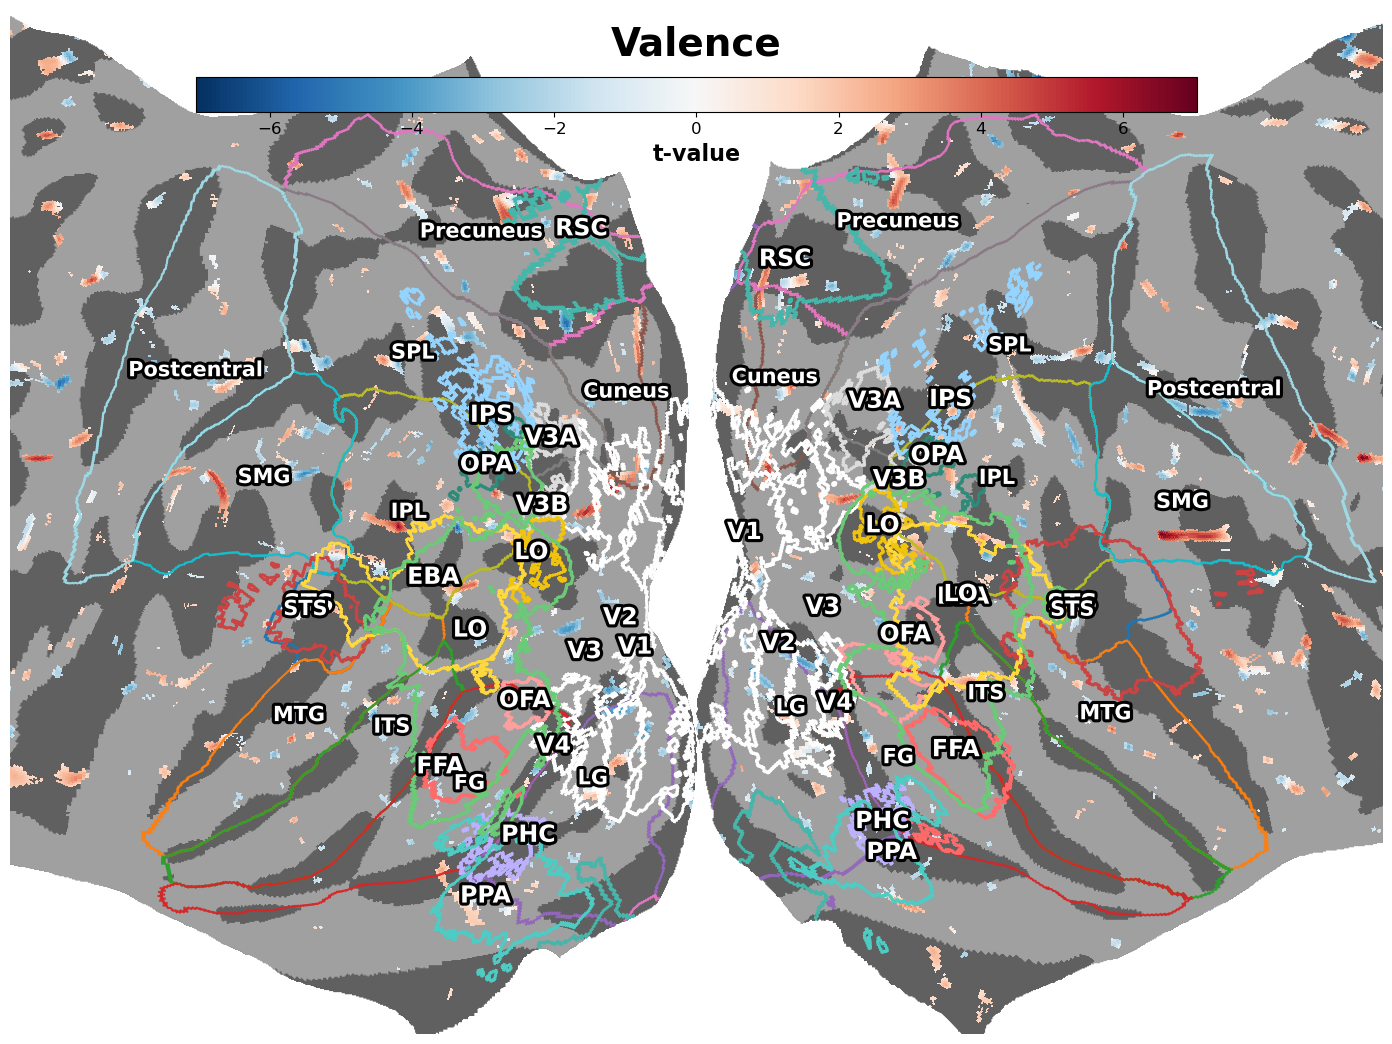

Saved /mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/visualization/pycortex/surface_plot_all_outputs/arousal_pycortex_flatmap.png


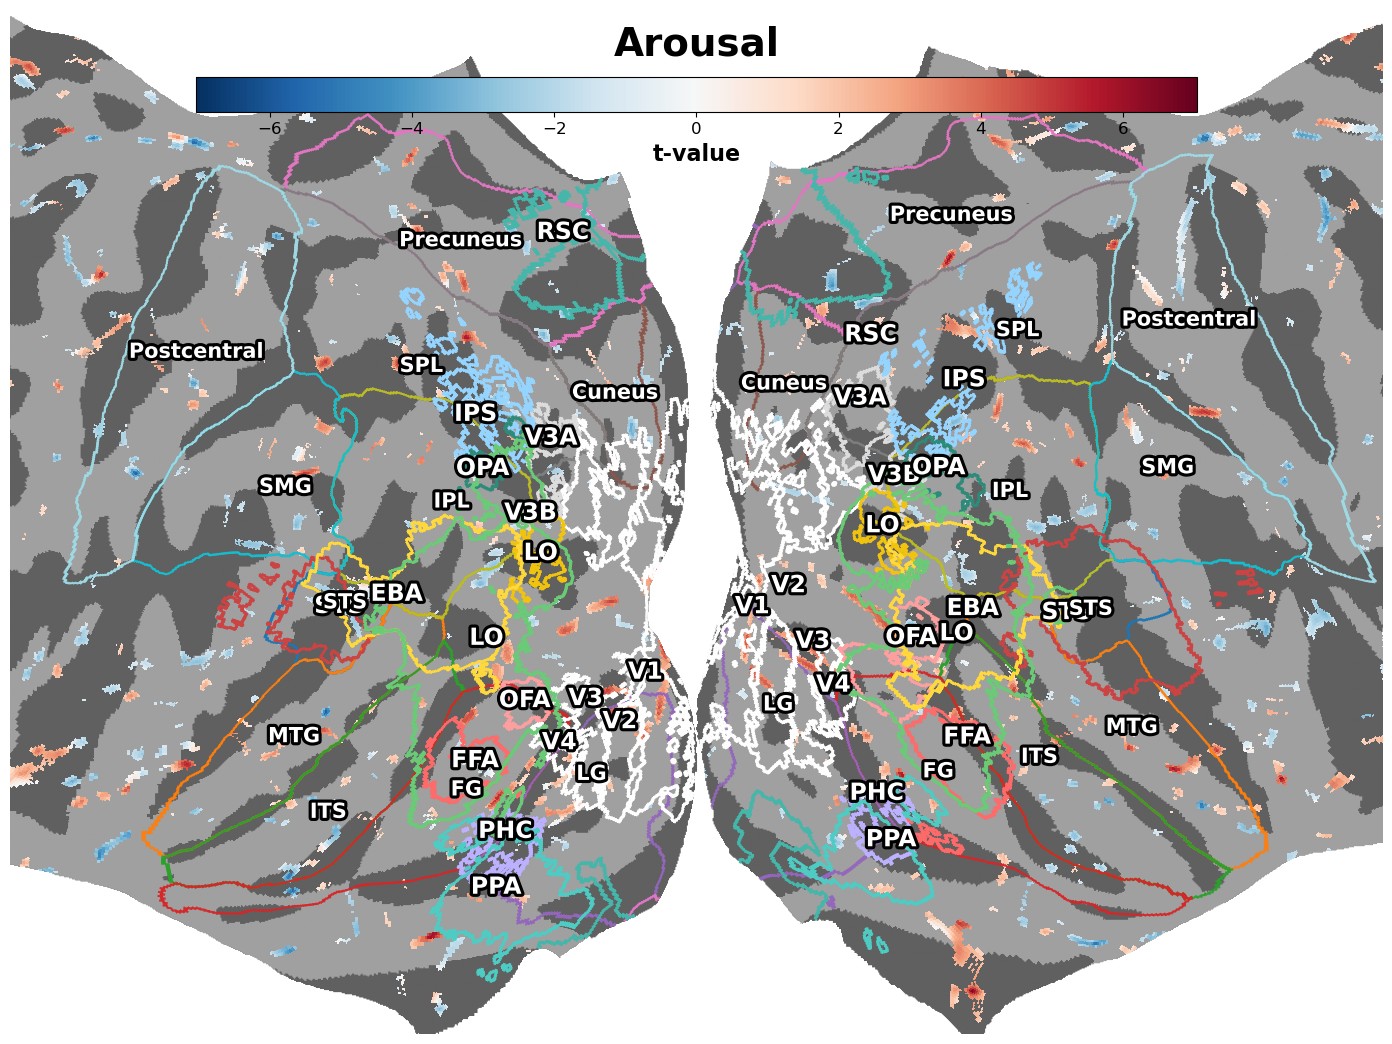

Saved /mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/visualization/pycortex/surface_plot_all_outputs/behavioral_rdm_rsa_pycortex_flatmap.png


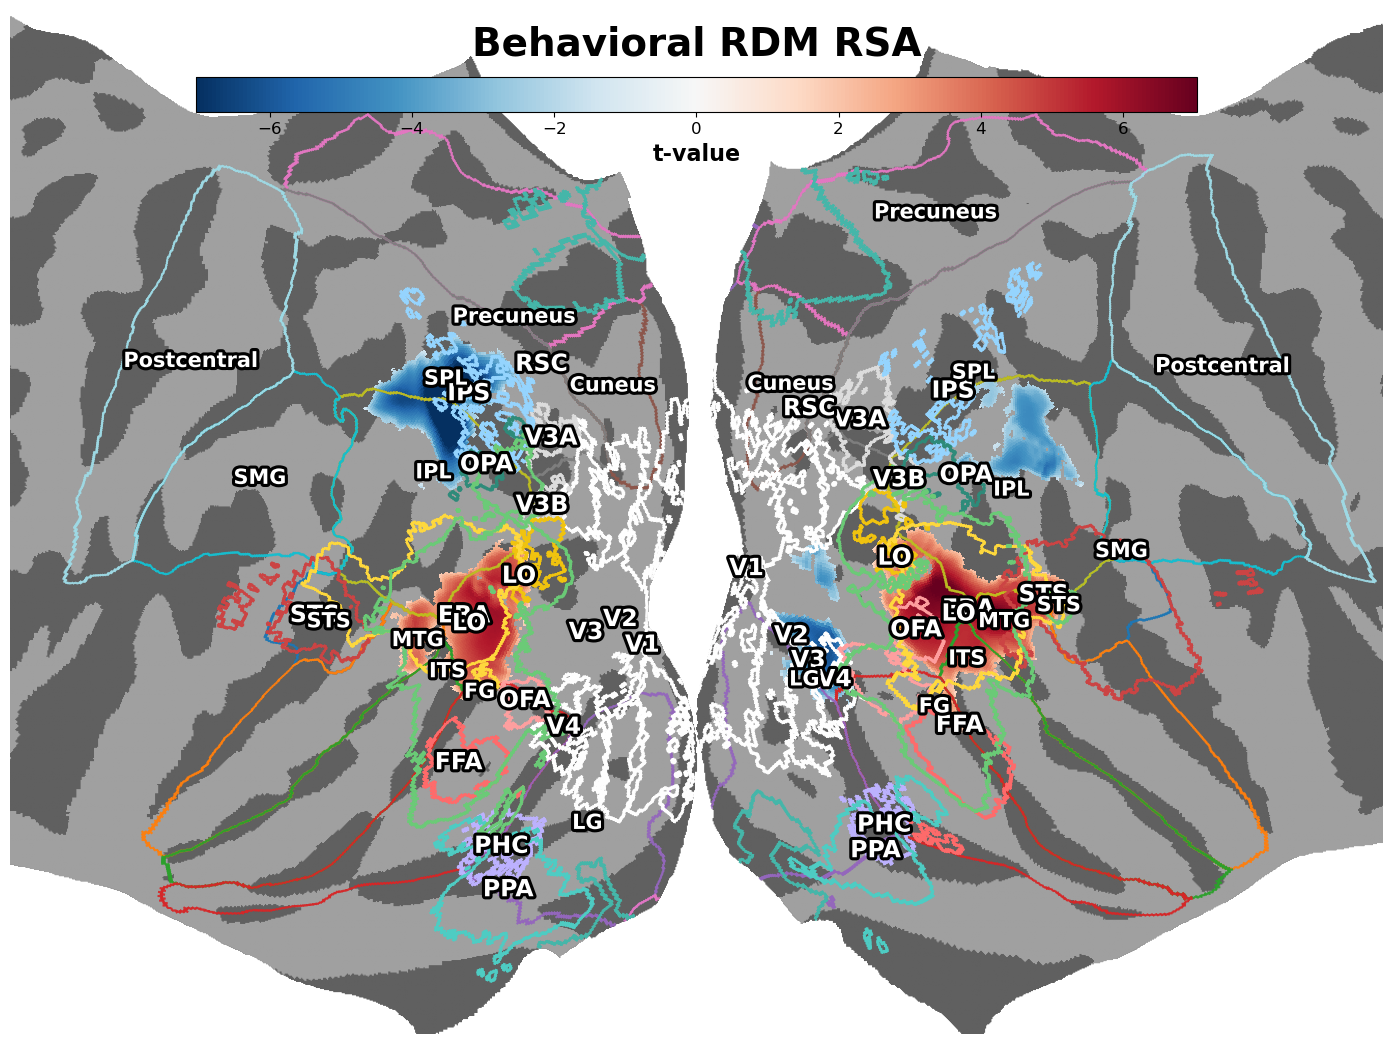

Saved combined figure: /mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/visualization/pycortex/surface_plot_all_outputs/valence_arousal_behavioral_rsa_pycortex_flatmaps_combined.png


In [4]:
def add_roi_boundaries_and_labels(ax, texture=None, label_fontsize=17):
    if not DRAW_ROIS:
        return

    for spec in ROI_SPECS:
        mask = spec["mask"]
        color = spec["color"]
        label = spec["label"]

        boundary_lines = []
        for tri in flat_polys:
            in_roi = mask[tri]
            if 0 < in_roi.sum() < 3:
                for j in range(3):
                    v1 = tri[j]
                    v2 = tri[(j + 1) % 3]
                    if mask[v1] != mask[v2]:
                        boundary_lines.append([flat_pts[v1, :2], flat_pts[v2, :2]])

        if boundary_lines:
            ax.add_collection(LineCollection(
                boundary_lines,
                colors=[color],
                linewidths=1.8 if spec["source"] != "aparc" else 1.4,
                alpha=0.95 if spec["source"] != "aparc" else 0.75,
                zorder=7 if spec["source"] != "aparc" else 5,
            ))

        if not DRAW_LABELS:
            continue

        hemi_masks = [mask.copy(), mask.copy()]
        hemi_masks[0][n_lh:] = False
        hemi_masks[1][:n_lh] = False

        for hemi_mask in hemi_masks:
            if hemi_mask.sum() == 0:
                continue
            sig_mask = hemi_mask & np.isfinite(texture) if texture is not None else np.zeros_like(hemi_mask, dtype=bool)
            pts = flat_pts[sig_mask] if sig_mask.sum() >= 8 else flat_pts[hemi_mask]
            if len(pts) == 0:
                continue
            cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
            ax.text(
                cx, cy, label,
                color="white",
                fontsize=label_fontsize if spec["source"] != "aparc" else label_fontsize - 2,
                fontweight="bold",
                ha="center",
                va="center",
                zorder=20,
                path_effects=[pe.withStroke(linewidth=4.5, foreground="black")],
            )


def make_flatmap(name, texture):
    vals = texture[np.isfinite(texture)]
    if len(vals) == 0:
        raise ValueError(f"No finite projected vertices for {name}")

    vmax = abs_tmax if abs_tmax is not None else float(np.nanpercentile(np.abs(vals), ROBUST_PERCENTILE))
    vmin = -vmax

    vertex_data = cortex.Vertex(texture, SUBJECT, cmap=CMAP, vmin=vmin, vmax=vmax)
    fig = cortex.quickflat.make_figure(
        vertex_data,
        with_curvature=True,
        with_colorbar=False,
        with_rois=False,
        with_sulci=False,
        with_labels=False,
        curvature_brightness=0.5,
        curvature_contrast=0.25,
        height=HEIGHT,
    )
    ax = fig.axes[0]
    add_roi_boundaries_and_labels(ax, texture=texture)

    if CROP_TO_OCCIPITAL_TEMPORAL:
        ax.set_xlim(*CROP_XLIM)
        ax.set_ylim(*CROP_YLIM)
        ax.set_aspect("equal")

    fig.text(0.5, 0.985, name, ha="center", va="top", fontsize=28, fontweight="bold")

    if DRAW_COLORBAR:
        cbar_ax = fig.add_axes([0.28, 0.90, 0.44, 0.035])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        sm = cm.ScalarMappable(cmap=CMAP, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        cbar.set_label("t-value", fontsize=16, fontweight="bold")
        cbar.ax.tick_params(labelsize=12)

    stem = name.lower().replace(" ", "_")
    out_png = OUT_DIR / f"{stem}_pycortex_flatmap.png"
    out_svg = OUT_DIR / f"{stem}_pycortex_flatmap.svg"
    fig.savefig(out_png, dpi=SAVE_DPI, bbox_inches="tight")
    fig.savefig(out_svg, bbox_inches="tight")
    print(f"Saved {out_png}")
    return fig, out_png


figures = {}
png_paths = []
for name, texture in textures.items():
    fig, out_png = make_flatmap(name, texture)
    figures[name] = fig
    png_paths.append(out_png)
    plt.show()

imgs = [Image.open(p).convert("RGB") for p in png_paths]
width = max(im.width for im in imgs)
height = sum(im.height for im in imgs)
combined = Image.new("RGB", (width, height), "white")
y = 0
for im in imgs:
    x = (width - im.width) // 2
    combined.paste(im, (x, y))
    y += im.height
combined_path = OUT_DIR / "valence_arousal_behavioral_rsa_pycortex_flatmaps_combined.png"
combined.save(combined_path)
print(f"Saved combined figure: {combined_path}")

In [5]:
summary_rows = []
for name, texture in textures.items():
    vals = texture[np.isfinite(texture)]
    summary_rows.append({
        "map": name,
        "surface_vertices_shown": len(vals),
        "min_t": float(np.nanmin(vals)),
        "max_t": float(np.nanmax(vals)),
        "mean_t": float(np.nanmean(vals)),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUT_DIR / "surface_plot_all_value_summary.csv", index=False)
print(OUT_DIR)

,map,surface_vertices_shown,min_t,max_t,mean_t
0,Valence,17167,-6.576046,7.016175,0.418360
1,Arousal,17558,-5.723763,7.514107,0.270040
2,Behavioral RDM RSA,12567,-10.777670,7.222144,0.361112


/mnt/n/Experimental_Data/yujunchen/projects/IAPS_Searchlight/visualization/pycortex/surface_plot_all_outputs
